In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/unsupervised_files/study_hours.csv")

In [ ]:
df

,Unnamed: 0,Study_Hours,Exam_Score
0,0,24.264664,64.657487
1,1,22.357262,72.128936
2,2,22.261474,70.396688
3,3,23.441185,64.278301
4,4,25.824502,71.802608
...,...,...,...
1495,1495,14.107012,78.837862
1496,1496,22.221010,77.099930
1497,1497,19.820106,75.154423
1498,1498,18.835305,76.450343


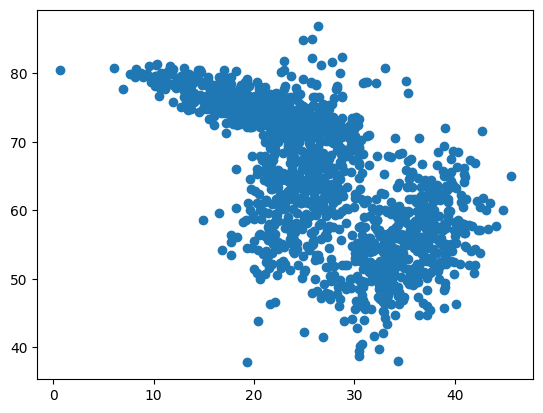

In [ ]:
plt.scatter(df['Study_Hours'],df['Exam_Score'])

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[["Study_Hours", "Exam_Score"]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
import scipy.cluster.hierarchy as sch



# Refer https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage
Z = sch.linkage(X_scaled, method='complete')

In [ ]:
# Z[0] = [23, 88, 0.12, 2]
# Point 23 and point 88 were merged

# Distance between them = 0.12

# New cluster contains 2 original samples

In [ ]:
Z

array([[4.91000000e+02, 1.46500000e+03, 2.20464768e-03, 2.00000000e+00],
       [5.96000000e+02, 7.07000000e+02, 2.41944555e-03, 2.00000000e+00],
       [1.24000000e+03, 1.36500000e+03, 2.52304544e-03, 2.00000000e+00],
       ...,
       [2.98000000e+03, 2.99400000e+03, 1.84642715e+01, 6.21000000e+02],
       [2.99300000e+03, 2.99600000e+03, 3.00765251e+01, 9.96000000e+02],
       [2.99500000e+03, 2.99700000e+03, 5.83239958e+01, 1.50000000e+03]])

Text(0, 0.5, 'distance')

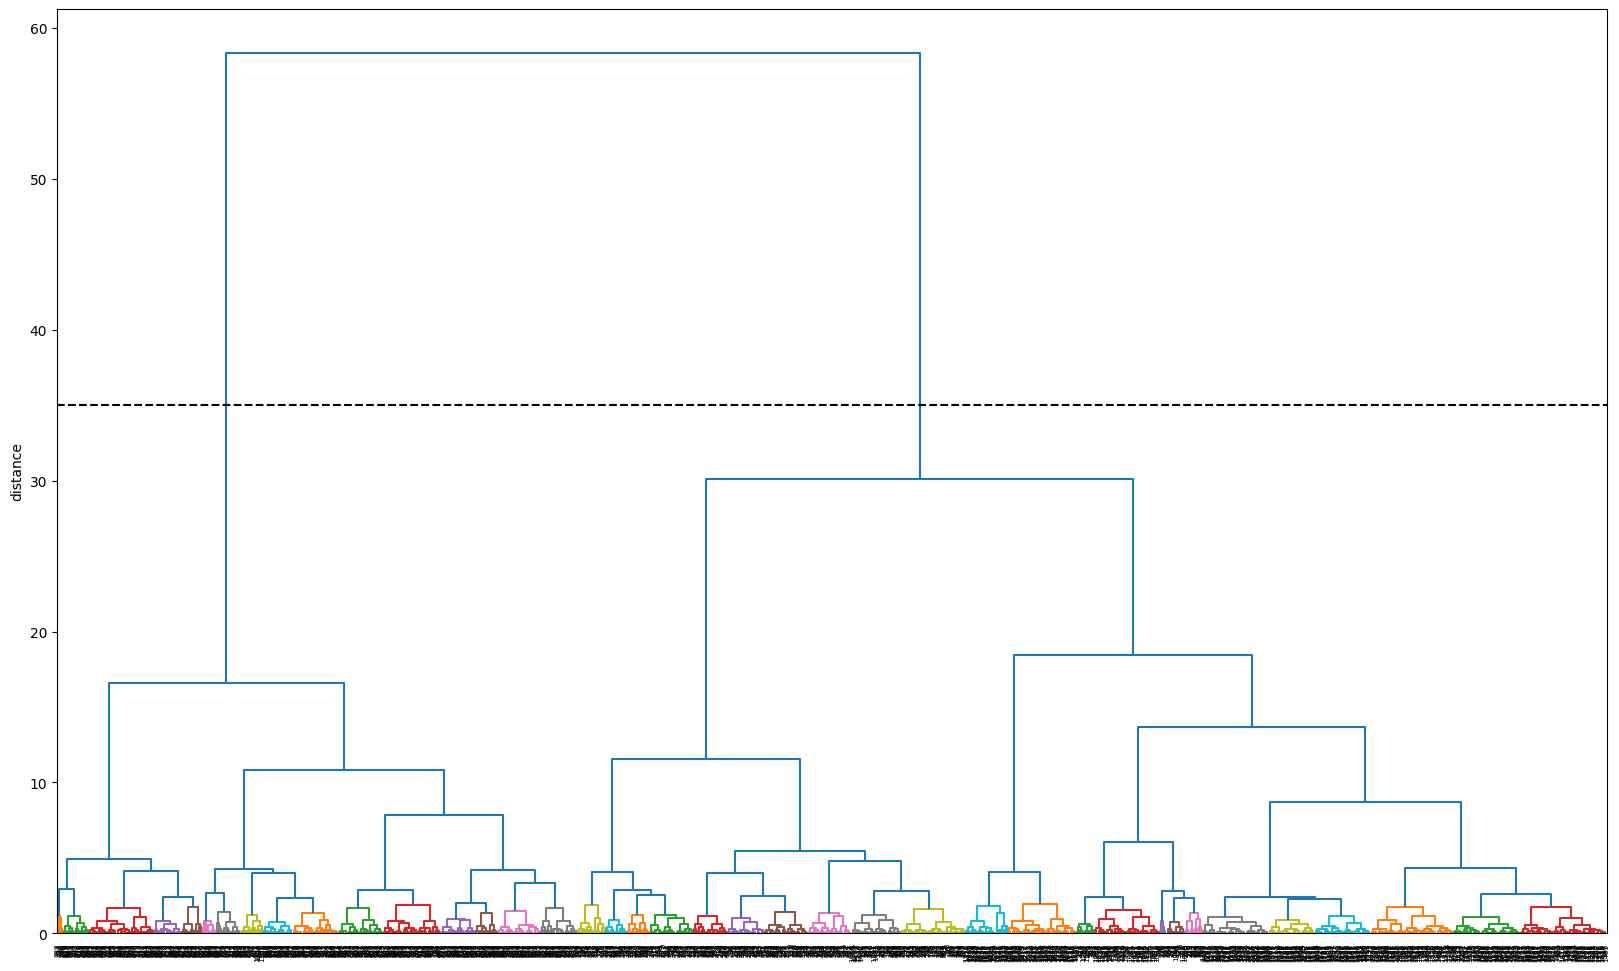

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
sch.dendrogram(Z, labels=df.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
plt.axhline(y=35, color='k', linestyle='--')
ax.set_ylabel('distance')

In [ ]:
import scipy.cluster.hierarchy as sch



# Refer https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage
Z = sch.linkage(X_scaled, method='single')

Text(0, 0.5, 'distance')

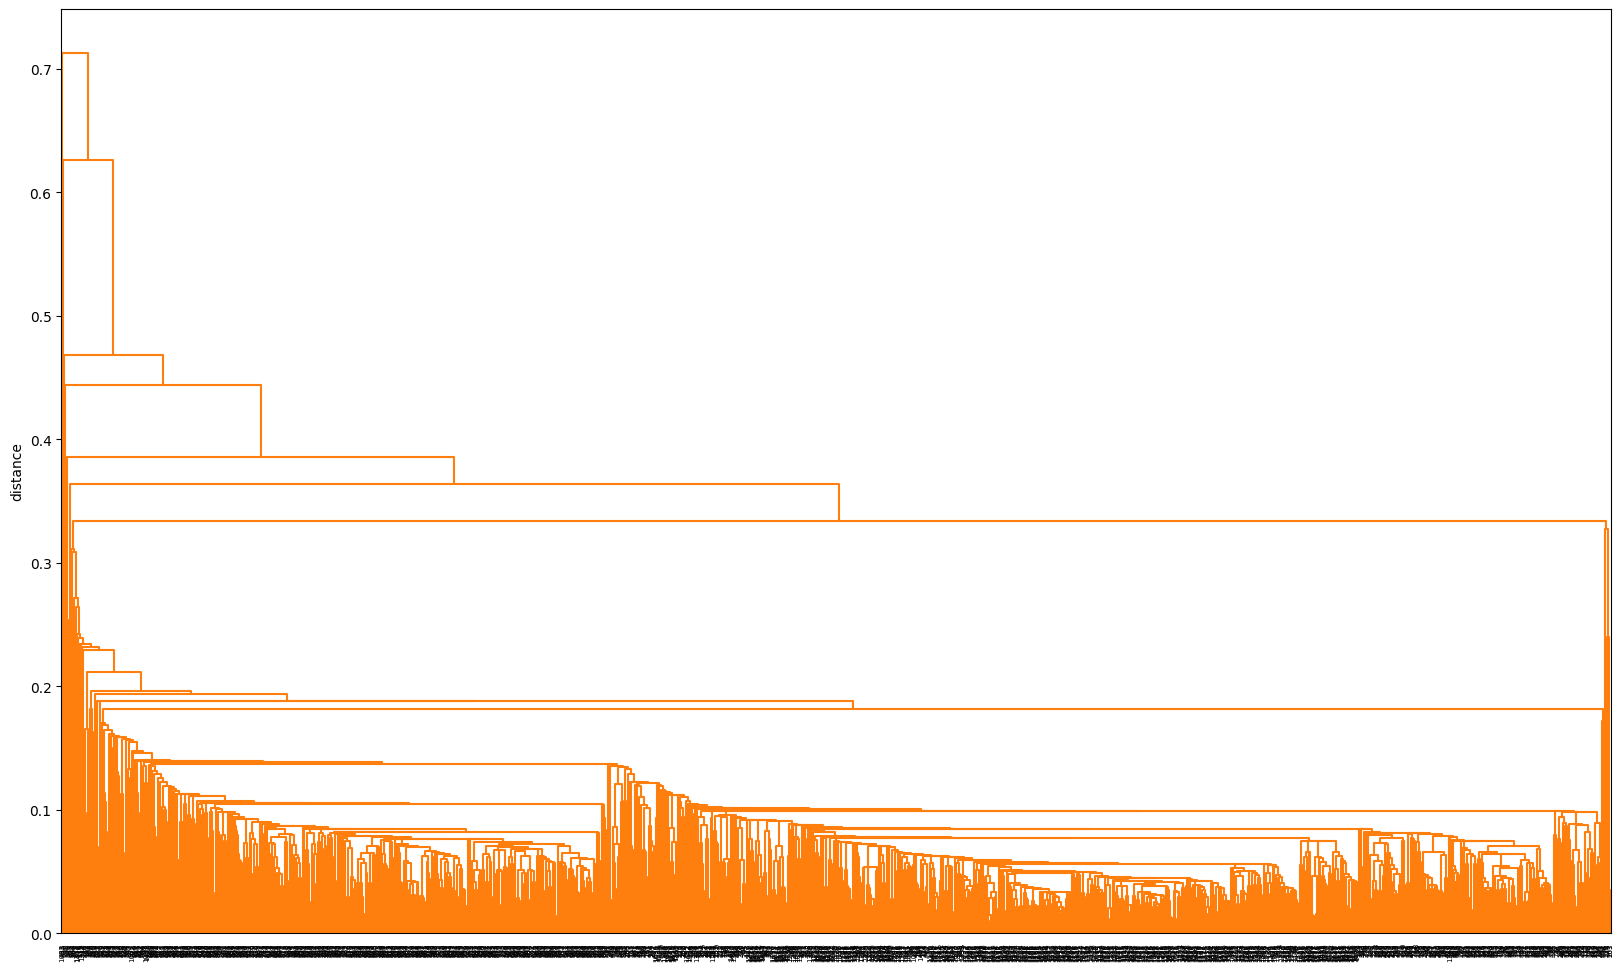

In [ ]:
fig, ax = plt.subplots(figsize=(20, 12))
sch.dendrogram(Z, labels=df.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)
plt.axhline(y=35, color='k', linestyle='--')
ax.set_ylabel('distance')

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(
    n_clusters=2,
    linkage='complete'
)
y_pred = agg.fit_predict(X_scaled)

In [ ]:
df["cluster"] = y_pred

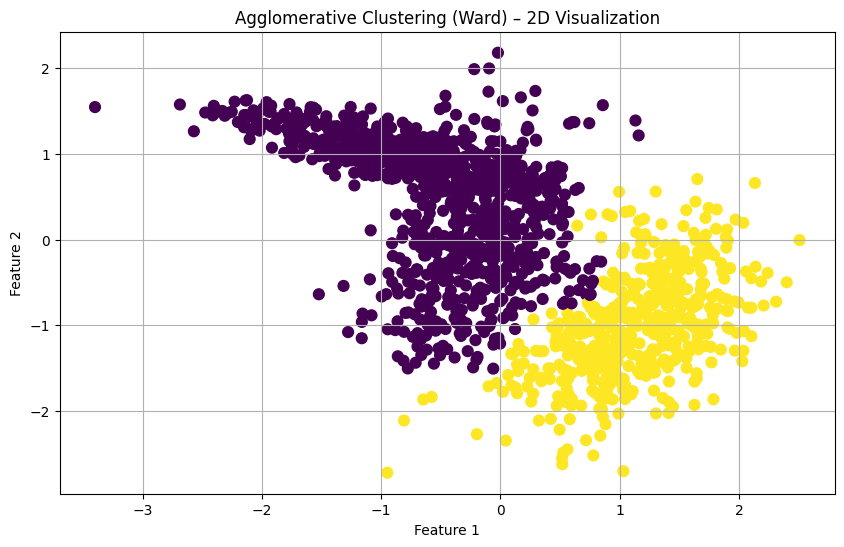

In [ ]:
x1 = X_scaled[:, 0]
x2 = X_scaled[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(x1, x2, c=df["cluster"], s=60)
plt.title("Agglomerative Clustering (Ward) – 2D Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 11):  # k = 2 to 10
    model = AgglomerativeClustering(n_clusters=k, linkage='complete')
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores[k] = score

scores

{2: np.float64(0.4898051029860061),
 3: np.float64(0.35757688648686325),
 4: np.float64(0.2703130457731508),
 5: np.float64(0.308638809308358),
 6: np.float64(0.2914804800328355),
 7: np.float64(0.2706035331239989),
 8: np.float64(0.291092720042743),
 9: np.float64(0.2849932902252905),
 10: np.float64(0.3094097630645852)}

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/unsupervised_files/products_data.csv')

In [ ]:
df

,Unnamed: 0,price,performance_score,battery,portability_score,true_label
0,0,10496.714153,39.308678,10.647689,9.523030,phone_budget
1,1,9765.846625,38.829315,11.579213,8.767435,phone_budget
2,2,9530.525614,42.712800,9.536582,7.534270,phone_budget
3,3,10241.962272,30.433599,8.275082,7.437712,phone_budget
4,4,8987.168880,41.571237,9.091976,6.587696,phone_budget
...,...,...,...,...,...,...
458,458,1095.313663,21.435621,14.387563,10.361504,charger
459,459,885.627379,20.542799,14.966770,9.791883,charger
460,460,987.146249,10.590755,14.451275,10.092845,charger
461,461,1015.985639,14.861624,16.265708,9.133825,charger


In [ ]:
df['true_label'].unique()

array(['phone_budget', 'phone_mid', 'phone_premium', 'laptop_budget',
       'laptop_gaming', 'laptop_ultrabook', 'audio', 'charger'],
      dtype=object)

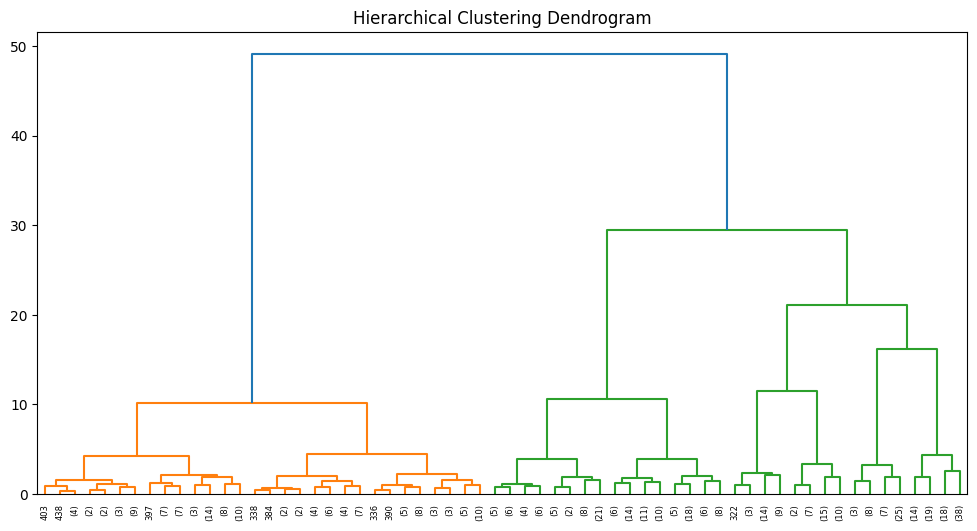

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = df.drop('true_label', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# choose number of clusters
k = 4

model = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

df['cluster'] = model.fit_predict(X_scaled)

In [ ]:
pd.crosstab(df['true_label'], df['cluster'])

cluster,0,1,2,3
true_label,,,,
audio,0,0,0,63
charger,0,0,0,72
laptop_budget,89,0,0,0
laptop_gaming,43,0,0,0
laptop_ultrabook,0,27,0,0
phone_budget,0,0,57,0
phone_mid,0,0,78,0
phone_premium,0,34,0,0


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# choose number of clusters
k = 4

model = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

df['cluster'] = model.fit_predict(X_scaled)

In [ ]:
pd.crosstab(df['true_label'], df['cluster'])

cluster,0,1,2,3
true_label,,,,
audio,0,0,63,0
charger,0,0,72,0
laptop_budget,89,0,0,0
laptop_gaming,43,0,0,0
laptop_ultrabook,0,0,0,27
phone_budget,0,57,0,0
phone_mid,0,78,0,0
phone_premium,0,0,0,34
